ДАТАСЕТ ДИАБЕТА
Размер: (768, 9)
Колонки: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Классы: {0: 500, 1: 268}

РАЗМЕРЫ ВЫБОРОК:
Обучающая: (614, 8)
Тестовая: (154, 8)
Соотношение классов в обучающей: [400 214]

ОБЩИЕ ПАРАМЕТРЫ ДЛЯ ВСЕХ МОДЕЛЕЙ
1. MAX_DEPTH = 4
   • Влияние: Ограничивает максимальную глубину дерева
   • Больше → сложнее модель, может переобучиться
   • Меньше → проще модель, меньше переобучение

2. MIN_SAMPLES_SPLIT = 10
   • Влияние: Минимальное количество образцов для разбиения узла
   • Больше → меньше разбиений, проще дерево
   • Меньше → больше разбиений, сложнее дерево

3. MIN_SAMPLES_LEAF = 5
   • Влияние: Минимальное количество образцов в листе
   • Больше → больше обобщение, меньше переобучение
   • Меньше → более точная подгонка к данным

4. MIN_GAIN_RATIO = 0.01 (C4.5)
   MIN_IMPURITY_DECREASE = 0.01 (scikit-learn)
   • Влияние: Минимальное улучшение для создания разбиения
   • 

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_16648\3369955890.py:639: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(metrics_names, rotation=45)


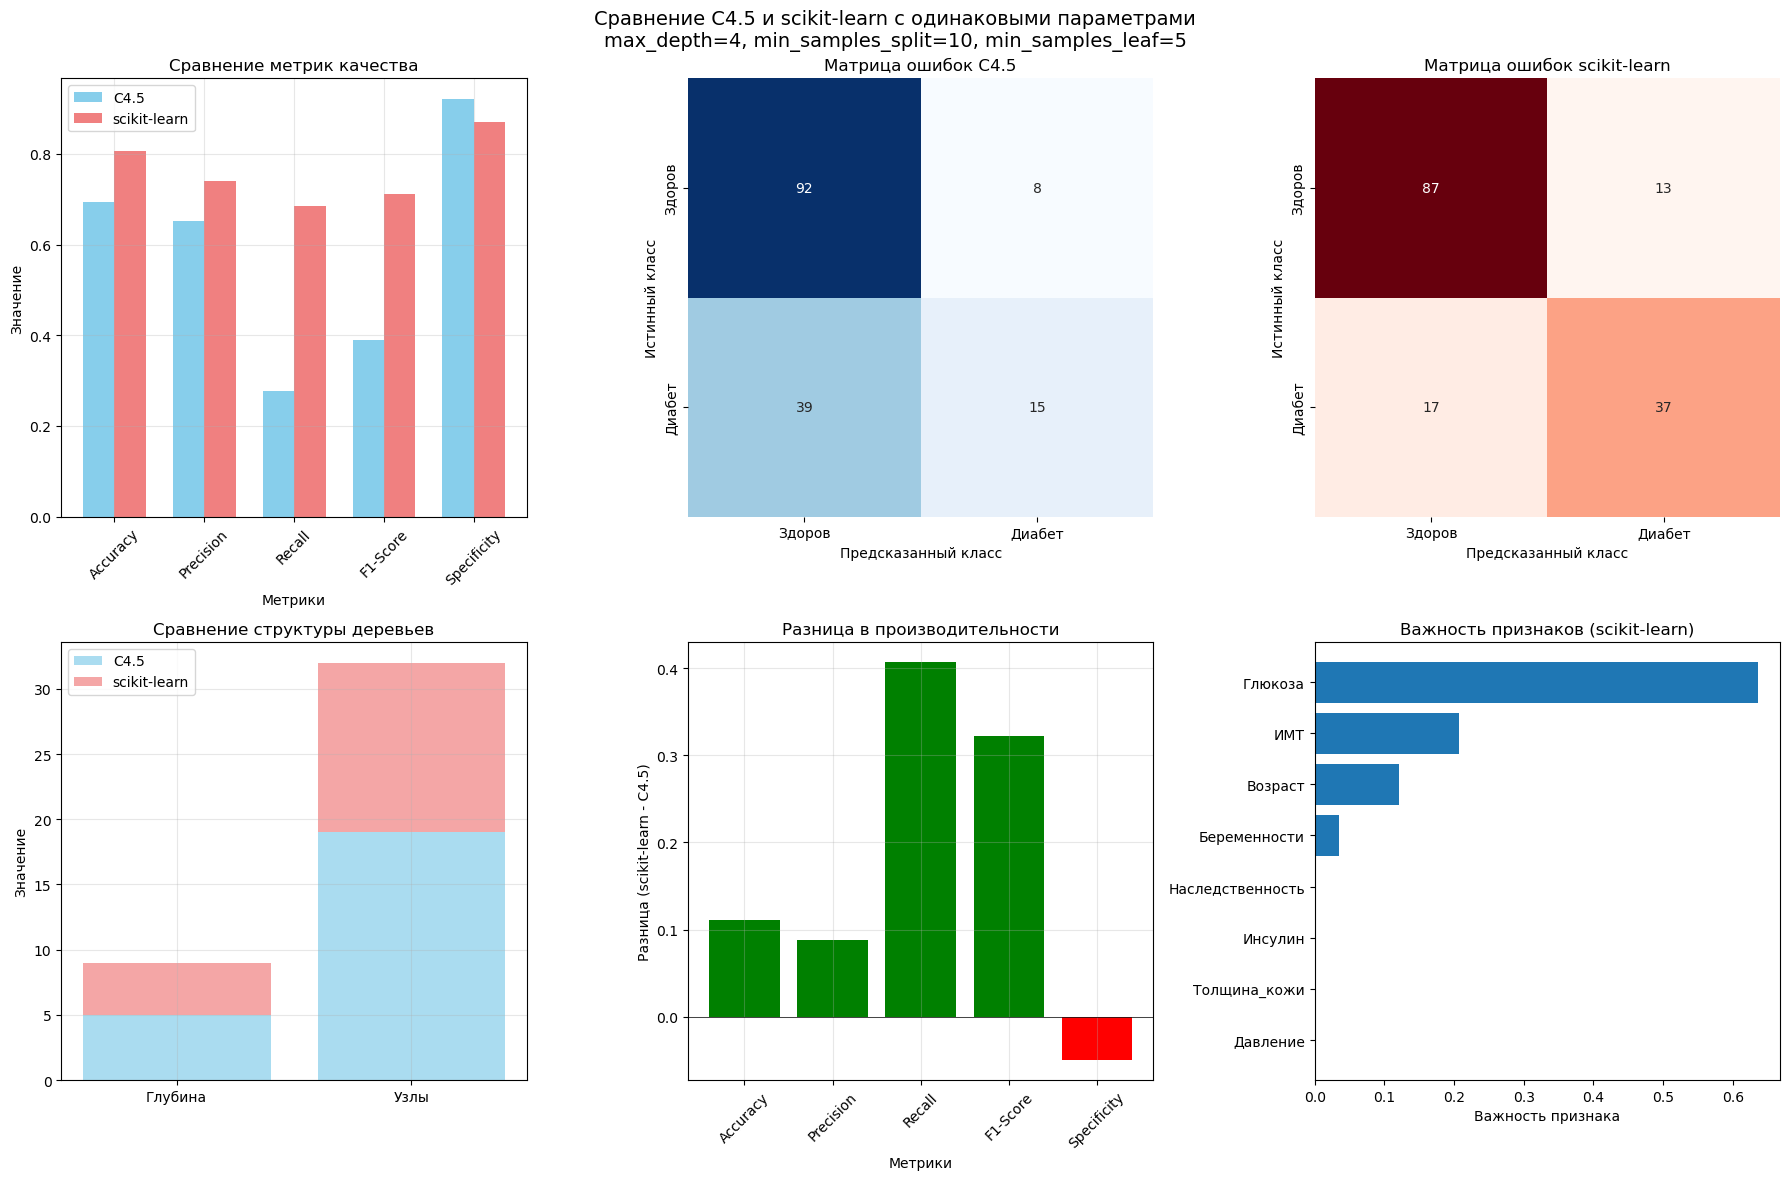


АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ АЛГОРИТМАМИ

ПОЧЕМУ SCIKIT-LEARN МОЖЕТ БЫТЬ ЛУЧШЕ ДАЖЕ ПРИ ОДИНАКОВЫХ ПАРАМЕТРАХ:
1. ОПТИМИЗИРОВАННЫЙ ПОИСК ПОРОГОВ:
   • scikit-learn: Использует эффективные алгоритмы поиска оптимальных порогов
   • C4.5 (наша реализация): Проверяет ограниченное количество порогов

2. ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:
   • scikit-learn: Встроенная оптимизированная обработка
   • C4.5: Простая обработка (игнорирование нулей)

3. ВЕКТОРИЗАЦИЯ ВЫЧИСЛЕНИЙ:
   • scikit-learn: Использует numpy для быстрых векторных операций
   • C4.5: Много циклов и рекурсивных вызовов

4. КРИТЕРИЙ MIN_IMPURITY_DECREASE vs MIN_GAIN_RATIO:
   • scikit-learn: min_impurity_decrease работает с Information Gain
   • C4.5: min_gain_ratio работает с Gain Ratio (более строгий)

5. ДОПОЛНИТЕЛЬНЫЕ ОПТИМИЗАЦИИ:
   • scikit-learn: Предвычисления, кэширование, оптимизация памяти
   • C4.5: Базовая реализация без оптимизаций

СТРУКТУРА ДЕРЕВЬЕВ

C4.5 ДЕРЕВО:
  • Глубина: 5
  • Узлов: 19
  • Листьев: 15 (приблизитель

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns
import math

# ============================================
# ОБЩИЕ ПАРАМЕТРЫ ДЛЯ ВСЕХ МОДЕЛЕЙ
# ============================================

# 1. МАКСИМАЛЬНАЯ ГЛУБИНА ДЕРЕВА
# Влияние: Ограничивает максимальную глубину дерева
# - Больше глубина → сложнее модель, лучше обучается, но может переобучиться
# - Меньше глубина → проще модель, меньше переобучение, но может недообучиться
MAX_DEPTH = 4

# 2. МИНИМАЛЬНОЕ КОЛИЧЕСТВО ОБРАЗЦОВ ДЛЯ РАЗБИЕНИЯ
# Влияние: Минимальное количество образцов в узле для создания разбиения
# - Больше значение → меньше разбиений, проще дерево
# - Меньше значение → больше разбиений, сложнее дерево
MIN_SAMPLES_SPLIT = 10

# 3. МИНИМАЛЬНОЕ КОЛИЧЕСТВО ОБРАЗЦОВ В ЛИСТЕ
# Влияние: Минимальное количество образцов в листовом узле
# - Больше значение → больше обобщение, меньше переобучение
# - Меньше значение → более точная подгонка к данным
MIN_SAMPLES_LEAF = 5

# 4. МИНИМАЛЬНЫЙ ПРИРОСТ ИНФОРМАЦИИ (Gain Ratio для C4.5)
# Влияние: Минимальное улучшение качества для создания разбиения
# - Больше значение → только значимые разбиения, проще дерево
# - Меньше значение → больше разбиений, сложнее дерево
MIN_GAIN_RATIO = 0.01  # Для C4.5
MIN_IMPURITY_DECREASE = 0.01  # Для scikit-learn (аналог min_gain_ratio)

# 5. КРИТЕРИЙ РАЗБИЕНИЯ
# Влияние: Функция для измерения качества разбиения
# - 'entropy': Информационный выигрыш (используется в C4.5)
# - 'gini': Индекс Джини (используется в CART)
CRITERION = 'entropy'

# 6. СТРАТЕГИЯ ВЫБОРА ЛУЧШЕГО РАЗБИЕНИЯ
# Влияние: Как выбирается лучшее разбиение в каждом узле
# - 'best': Выбирает лучшее разбиение (жадный алгоритм)
# - 'random': Выбирает случайное разбиение (для Random Forest)
SPLITTER = 'best'

# 7. СЛУЧАЙНОЕ СОСТОЯНИЕ (для воспроизводимости)
RANDOM_STATE = 42

# ============================================
# ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================

df = pd.read_csv('diabetes.csv')
print("="*80)
print("ДАТАСЕТ ДИАБЕТА")
print("="*80)
print(f"Размер: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print(f"Классы: {df['Outcome'].value_counts().to_dict()}")

# Переименование для удобства
column_names = {
    'Pregnancies': 'Беременности',
    'Glucose': 'Глюкоза',
    'BloodPressure': 'Давление',
    'SkinThickness': 'Толщина_кожи',
    'Insulin': 'Инсулин',
    'BMI': 'ИМТ',
    'DiabetesPedigreeFunction': 'Наследственность',
    'Age': 'Возраст',
    'Outcome': 'Диабет'
}
df = df.rename(columns=column_names)

features = [col for col in df.columns if col != 'Диабет']
X = df[features].values  
y = df['Диабет'].values  

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nРАЗМЕРЫ ВЫБОРОК:")
print(f"Обучающая: {X_train.shape}")
print(f"Тестовая: {X_test.shape}")
print(f"Соотношение классов в обучающей: {np.bincount(y_train)}")

# ============================================
# ВЫВОД ОБЩИХ ПАРАМЕТРОВ
# ============================================

print("\n" + "="*80)
print("ОБЩИЕ ПАРАМЕТРЫ ДЛЯ ВСЕХ МОДЕЛЕЙ")
print("="*80)
print(f"1. MAX_DEPTH = {MAX_DEPTH}")
print(f"   • Влияние: Ограничивает максимальную глубину дерева")
print(f"   • Больше → сложнее модель, может переобучиться")
print(f"   • Меньше → проще модель, меньше переобучение\n")

print(f"2. MIN_SAMPLES_SPLIT = {MIN_SAMPLES_SPLIT}")
print(f"   • Влияние: Минимальное количество образцов для разбиения узла")
print(f"   • Больше → меньше разбиений, проще дерево")
print(f"   • Меньше → больше разбиений, сложнее дерево\n")

print(f"3. MIN_SAMPLES_LEAF = {MIN_SAMPLES_LEAF}")
print(f"   • Влияние: Минимальное количество образцов в листе")
print(f"   • Больше → больше обобщение, меньше переобучение")
print(f"   • Меньше → более точная подгонка к данным\n")

print(f"4. MIN_GAIN_RATIO = {MIN_GAIN_RATIO} (C4.5)")
print(f"   MIN_IMPURITY_DECREASE = {MIN_IMPURITY_DECREASE} (scikit-learn)")
print(f"   • Влияние: Минимальное улучшение для создания разбиения")
print(f"   • Больше → только значимые разбиения")
print(f"   • Меньше → больше разбиений\n")

print(f"5. CRITERION = '{CRITERION}'")
print(f"   • Влияние: Функция для измерения качества разбиения")
print(f"   • 'entropy': Информационный выигрыш (C4.5)")
print(f"   • 'gini': Индекс Джини (CART)\n")

print(f"6. SPLITTER = '{SPLITTER}'")
print(f"   • Влияние: Стратегия выбора лучшего разбиения")
print(f"   • 'best': Жадный алгоритм")
print(f"   • 'random': Случайный выбор\n")

print(f"7. RANDOM_STATE = {RANDOM_STATE}")
print(f"   • Влияние: Обеспечивает воспроизводимость результатов")

# ============================================
# УЗЕЛ ДЕРЕВА C4.5
# ============================================

class NodeC45:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, 
                 value=None, is_leaf=False, split_info=0, gain_ratio=0, samples=None):
        # ИНДЕКС ПРИЗНАКА ДЛЯ РАЗБИЕНИЯ
        self.feature_index = feature_index
        # ПОРОГОВОЕ ЗНАЧЕНИЕ (для непрерывных признаков)
        self.threshold = threshold
        # ЛЕВЫЙ ПОТОМОК (значения <= threshold)
        self.left = left
        # ПРАВЫЙ ПОТОМОК (значения > threshold)
        self.right = right
        # ЗНАЧЕНИЕ В ЛИСТЕ (класс для листового узла)
        self.value = value
        # ФЛАГ ЛИСТОВОГО УЗЛА
        self.is_leaf = is_leaf
        # ИНФОРМАЦИЯ РАЗБИЕНИЯ (Split Info)
        self.split_info = split_info
        # КОЭФФИЦИЕНТ УСИЛЕНИЯ (Gain Ratio)
        self.gain_ratio = gain_ratio
        # КОЛИЧЕСТВО ОБРАЗЦОВ В УЗЛЕ
        self.samples = samples

# ============================================
# КЛАСС ДЕРЕВА РЕШЕНИЙ C4.5
# ============================================

class C45DecisionTree:
    def __init__(self, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES_SPLIT, 
                 min_samples_leaf=MIN_SAMPLES_LEAF, min_gain_ratio=MIN_GAIN_RATIO):
        
        # ПАРАМЕТРЫ ДЕРЕВА (идентичные scikit-learn)
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_gain_ratio = min_gain_ratio
        
        # КОРЕНЬ ДЕРЕВА
        self.root = None
        # НАЗВАНИЯ ПРИЗНАКОВ
        self.feature_names = None
    
    # ============================================
    # ВСПОМОГАТЕЛЬНЫЕ МЕТОДЫ
    # ============================================
    
    def calculate_entropy(self, y):
        """ВЫЧИСЛЕНИЕ ЭНТРОПИИ (мера неопределенности)"""
        if len(y) == 0:
            return 0
        
        # Подсчет вероятностей каждого класса
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        
        # Формула энтропии: H = -Σ p_i * log2(p_i)
        entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
        return entropy
    
    def calculate_split_info(self, splits):
        """ВЫЧИСЛЕНИЕ ИНФОРМАЦИИ РАЗБИЕНИЯ (Split Info)"""
        total = sum(len(split) for split in splits)
        if total == 0:
            return 0
        
        split_info = 0
        for split in splits:
            if len(split) > 0:
                ratio = len(split) / total
                # Split Info = -Σ (|D_i|/|D|) * log2(|D_i|/|D|)
                split_info -= ratio * np.log2(ratio + 1e-10)
        return split_info
    
    def find_best_threshold(self, feature_values, y):
        """ПОИСК ЛУЧШЕГО ПОРОГА ДЛЯ НЕПРЕРЫВНОГО ПРИЗНАКА"""
        best_gain_ratio = -1
        best_threshold = None
        best_left_indices = None
        best_right_indices = None
        best_split_info = 0
        
        # Уникальные значения признака (исключаем пропуски)
        unique_values = np.unique(feature_values[feature_values != 0])
        
        if len(unique_values) <= 1:
            return best_gain_ratio, best_threshold, best_left_indices, best_right_indices, best_split_info
        
        # Проверяем возможные пороги (медиану и квантили)
        thresholds_to_check = [
            np.median(unique_values),
            np.percentile(unique_values, 25),
            np.percentile(unique_values, 75),
            np.mean(unique_values)
        ]
        
        # Добавляем пороги между соседними значениями
        sorted_values = np.sort(unique_values)
        if len(sorted_values) > 10:
            # Берем каждое 5-е значение для скорости
            thresholds_to_check.extend(sorted_values[::5])
        else:
            thresholds_to_check.extend(sorted_values)
        
        thresholds_to_check = np.unique(thresholds_to_check)
        
        for threshold in thresholds_to_check:
            # РАЗБИЕНИЕ ДАННЫХ
            left_indices = feature_values <= threshold
            right_indices = feature_values > threshold
            
            # ПРОВЕРКА УСЛОВИЙ MIN_SAMPLES_LEAF
            if (np.sum(left_indices) < self.min_samples_leaf or 
                np.sum(right_indices) < self.min_samples_leaf):
                continue
            
            # ВЫЧИСЛЕНИЕ ЭНТРОПИИ
            entropy_parent = self.calculate_entropy(y)
            entropy_left = self.calculate_entropy(y[left_indices])
            entropy_right = self.calculate_entropy(y[right_indices])
            
            # ИНФОРМАЦИОННЫЙ ПРИРОСТ (Information Gain)
            n_left = np.sum(left_indices)
            n_right = np.sum(right_indices)
            total_samples = n_left + n_right
            
            info_gain = entropy_parent - (n_left/total_samples * entropy_left + 
                                         n_right/total_samples * entropy_right)
            
            # ИНФОРМАЦИЯ РАЗБИЕНИЯ (Split Info)
            split_info = self.calculate_split_info([y[left_indices], y[right_indices]])
            
            # КОЭФФИЦИЕНТ УСИЛЕНИЯ (Gain Ratio)
            if split_info > 0:
                gain_ratio = info_gain / split_info
            else:
                gain_ratio = 0
            
            # ВЫБОР ЛУЧШЕГО РАЗБИЕНИЯ
            if gain_ratio > best_gain_ratio:
                best_gain_ratio = gain_ratio
                best_threshold = threshold
                best_left_indices = left_indices
                best_right_indices = right_indices
                best_split_info = split_info
        
        return best_gain_ratio, best_threshold, best_left_indices, best_right_indices, best_split_info
    
    def find_best_split(self, X, y):
        """ПОИСК ЛУЧШЕГО РАЗБИЕНИЯ ДЛЯ ВСЕХ ПРИЗНАКОВ"""
        best_gain_ratio = -1
        best_split = {}
        n_samples, n_features = X.shape
        
        # ПРОВЕРКА УСЛОВИЯ MIN_SAMPLES_SPLIT
        if n_samples < self.min_samples_split:
            return best_split
        
        current_entropy = self.calculate_entropy(y)
        
        # ПЕРЕБОР ВСЕХ ПРИЗНАКОВ
        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            
            # ПРОПУСКАЕМ ПРИЗНАКИ С МАЛЫМ РАЗНООБРАЗИЕМ
            unique_values = np.unique(feature_values[feature_values != 0])
            if len(unique_values) < 2:
                continue
            
            gain_ratio, threshold, left_indices, right_indices, split_info = \
                self.find_best_threshold(feature_values, y)
            
            # ПРОВЕРКА УСЛОВИЯ MIN_GAIN_RATIO
            if gain_ratio > best_gain_ratio and gain_ratio >= self.min_gain_ratio:
                best_gain_ratio = gain_ratio
                best_split = {
                    'feature_index': feature_index,
                    'threshold': threshold,
                    'left_indices': left_indices,
                    'right_indices': right_indices,
                    'gain_ratio': gain_ratio,
                    'split_info': split_info,
                    'info_gain': current_entropy - (
                        np.sum(left_indices)/n_samples * self.calculate_entropy(y[left_indices]) + 
                        np.sum(right_indices)/n_samples * self.calculate_entropy(y[right_indices])
                    )
                }
        
        return best_split
    
    def build_tree(self, X, y, depth=0):
        """РЕКУРСИВНОЕ ПОСТРОЕНИЕ ДЕРЕВА"""
        
        # ============================================
        # УСЛОВИЯ ОСТАНОВКИ РЕКУРСИИ (ПРЕДОТВРАЩЕНИЕ ПЕРЕОБУЧЕНИЯ)
        # ============================================
        
        # 1. ДОСТИГНУТА МАКСИМАЛЬНАЯ ГЛУБИНА
        if depth >= self.max_depth:
            value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            return NodeC45(value=value, is_leaf=True, samples=len(y))
        
        # 2. СЛИШКОМ МАЛО ОБРАЗЦОВ ДЛЯ РАЗБИЕНИЯ
        if len(y) < self.min_samples_split:
            value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            return NodeC45(value=value, is_leaf=True, samples=len(y))
        
        # 3. ВСЕ ОБРАЗЦЫ ОДНОГО КЛАССА (ЧИСТЫЙ УЗЕЛ)
        if len(np.unique(y)) == 1:
            value = y[0]
            return NodeC45(value=value, is_leaf=True, samples=len(y))
        
        # 4. ЭНТРОПИЯ ОЧЕНЬ НИЗКАЯ (УЗЕЛ ПОЧТИ ЧИСТЫЙ)
        if self.calculate_entropy(y) < 0.01:
            value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            return NodeC45(value=value, is_leaf=True, samples=len(y))
        
        # ============================================
        # ПОИСК ЛУЧШЕГО РАЗБИЕНИЯ
        # ============================================
        best_split = self.find_best_split(X, y)
        
        # ЕСЛИ НЕ НАЙДЕНО ДОСТАТОЧНО ХОРОШЕЕ РАЗБИЕНИЕ
        if not best_split:
            value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            return NodeC45(value=value, is_leaf=True, samples=len(y))
        
        # ============================================
        # СОЗДАНИЕ ВНУТРЕННЕГО УЗЛА
        # ============================================
        node = NodeC45(
            feature_index=best_split['feature_index'],
            threshold=best_split['threshold'],
            gain_ratio=best_split['gain_ratio'],
            split_info=best_split['split_info'],
            samples=len(y)
        )
        
        # ============================================
        # РЕКУРСИВНОЕ ПОСТРОЕНИЕ ПОДДЕРЕВЬЕВ
        # ============================================
        left_subtree = self.build_tree(
            X[best_split['left_indices']], 
            y[best_split['left_indices']], 
            depth + 1
        )
        
        right_subtree = self.build_tree(
            X[best_split['right_indices']], 
            y[best_split['right_indices']], 
            depth + 1
        )
        
        node.left = left_subtree
        node.right = right_subtree
        
        return node
    
    def fit(self, X, y, feature_names=None):
        """ОБУЧЕНИЕ ДЕРЕВА"""
        if feature_names is not None:
            self.feature_names = feature_names
        else:
            self.feature_names = [f"Признак_{i}" for i in range(X.shape[1])]
        
        self.root = self.build_tree(X, y)
    
    def predict_sample(self, x, node):
        """РЕКУРСИВНОЕ ПРЕДСКАЗАНИЕ ДЛЯ ОДНОГО ОБРАЗЦА"""
        if node.is_leaf:
            return node.value
        
        if x[node.feature_index] <= node.threshold:
            return self.predict_sample(x, node.left)
        else:
            return self.predict_sample(x, node.right)
    
    def predict(self, X):
        """ПРЕДСКАЗАНИЕ ДЛЯ ВСЕГО НАБОРА ДАННЫХ"""
        predictions = []
        for x in X:
            predictions.append(self.predict_sample(x, self.root))
        return np.array(predictions)
    
    def get_depth(self, node=None):
        """ВЫЧИСЛЕНИЕ ГЛУБИНЫ ДЕРЕВА"""
        if node is None:
            node = self.root
        if node.is_leaf:
            return 1
        return 1 + max(self.get_depth(node.left), self.get_depth(node.right))
    
    def get_node_count(self, node=None):
        """ПОДСЧЕТ КОЛИЧЕСТВА УЗЛОВ"""
        if node is None:
            node = self.root
        if node.is_leaf:
            return 1
        return 1 + self.get_node_count(node.left) + self.get_node_count(node.right)

# ============================================
# ОБУЧЕНИЕ МОДЕЛИ C4.5
# ============================================

print("\n" + "="*80)
print("ОБУЧЕНИЕ МОДЕЛИ C4.5")
print("="*80)

c45_tree = C45DecisionTree(
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    min_gain_ratio=MIN_GAIN_RATIO
)

print("Параметры C4.5:")
print(f"  • max_depth: {MAX_DEPTH}")
print(f"  • min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  • min_samples_leaf: {MIN_SAMPLES_LEAF}")
print(f"  • min_gain_ratio: {MIN_GAIN_RATIO}")

c45_tree.fit(X_train, y_train, feature_names=features)

# Предсказания C4.5
y_pred_c45 = c45_tree.predict(X_test)

# ============================================
# ОБУЧЕНИЕ МОДЕЛИ SCIKIT-LEARN
# ============================================

print("\n" + "="*80)
print("ОБУЧЕНИЕ МОДЕЛИ SCIKIT-LEARN")
print("="*80)

sklearn_tree = DecisionTreeClassifier(
    criterion=CRITERION,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    min_impurity_decrease=MIN_IMPURITY_DECREASE,
    splitter=SPLITTER,
    random_state=RANDOM_STATE
)

print("Параметры scikit-learn:")
print(f"  • criterion: '{CRITERION}'")
print(f"  • max_depth: {MAX_DEPTH}")
print(f"  • min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  • min_samples_leaf: {MIN_SAMPLES_LEAF}")
print(f"  • min_impurity_decrease: {MIN_IMPURITY_DECREASE}")
print(f"  • splitter: '{SPLITTER}'")
print(f"  • random_state: {RANDOM_STATE}")

sklearn_tree.fit(X_train, y_train)

# Предсказания scikit-learn
y_pred_sklearn = sklearn_tree.predict(X_test)

# ============================================
# ВЫЧИСЛЕНИЕ МЕТРИК
# ============================================

print("\n" + "="*80)
print("ВЫЧИСЛЕНИЕ МЕТРИК КАЧЕСТВА")
print("="*80)

def calculate_metrics(y_true, y_pred, model_name):
    """Вычисление всех метрик для модели"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Специфичность
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'confusion_matrix': cm,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn
    }

# Метрики для C4.5
metrics_c45 = calculate_metrics(y_test, y_pred_c45, "C4.5")
c45_depth = c45_tree.get_depth()
c45_nodes = c45_tree.get_node_count()

# Метрики для scikit-learn
metrics_sklearn = calculate_metrics(y_test, y_pred_sklearn, "scikit-learn")
sklearn_depth = sklearn_tree.get_depth()
sklearn_nodes = sklearn_tree.tree_.node_count

# ============================================
# ВЫВОД РЕЗУЛЬТАТОВ
# ============================================

print("\n" + "="*80)
print("СРАВНИТЕЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("="*80)

print(f"\n{'МЕТРИКА':<20} {'C4.5':<15} {'scikit-learn':<15} {'РАЗНИЦА':<15}")
print("-" * 65)

metrics_to_compare = ['accuracy', 'precision', 'recall', 'f1', 'specificity']
for metric in metrics_to_compare:
    c45_val = metrics_c45[metric]
    sklearn_val = metrics_sklearn[metric]
    diff = sklearn_val - c45_val
    
    print(f"{metric.upper():<20} {c45_val:<15.4f} {sklearn_val:<15.4f} {diff:<15.4f}")

print(f"\n{'ГЛУБИНА ДЕРЕВА':<20} {c45_depth:<15} {sklearn_depth:<15} {sklearn_depth - c45_depth:<15}")
print(f"{'КОЛ-ВО УЗЛОВ':<20} {c45_nodes:<15} {sklearn_nodes:<15} {sklearn_nodes - c45_nodes:<15}")

print("\n" + "="*80)
print("ДЕТАЛЬНЫЙ АНАЛИЗ МАТРИЦЫ ОШИБОК")
print("="*80)

print(f"\nМОДЕЛЬ C4.5:")
print(f"  True Positive (TP): {metrics_c45['tp']} - Правильно предсказанные 'Диабет'")
print(f"  True Negative (TN): {metrics_c45['tn']} - Правильно предсказанные 'Здоров'")
print(f"  False Positive (FP): {metrics_c45['fp']} - Ложные срабатывания (ошибка I рода)")
print(f"  False Negative (FN): {metrics_c45['fn']} - Пропущенные случаи (ошибка II рода)")

print(f"\nМОДЕЛЬ SCIKIT-LEARN:")
print(f"  True Positive (TP): {metrics_sklearn['tp']}")
print(f"  True Negative (TN): {metrics_sklearn['tn']}")
print(f"  False Positive (FP): {metrics_sklearn['fp']}")
print(f"  False Negative (FN): {metrics_sklearn['fn']}")

# ============================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Сравнение метрик
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity']
metrics_values_c45 = [metrics_c45[m] for m in ['accuracy', 'precision', 'recall', 'f1', 'specificity']]
metrics_values_sklearn = [metrics_sklearn[m] for m in ['accuracy', 'precision', 'recall', 'f1', 'specificity']]

x = np.arange(len(metrics_names))
width = 0.35

axes[0, 0].bar(x - width/2, metrics_values_c45, width, label='C4.5', color='skyblue')
axes[0, 0].bar(x + width/2, metrics_values_sklearn, width, label='scikit-learn', color='lightcoral')
axes[0, 0].set_xlabel('Метрики')
axes[0, 0].set_ylabel('Значение')
axes[0, 0].set_title('Сравнение метрик качества')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_names, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Матрица ошибок C4.5
sns.heatmap(metrics_c45['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
            ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Матрица ошибок C4.5')
axes[0, 1].set_xlabel('Предсказанный класс')
axes[0, 1].set_ylabel('Истинный класс')
axes[0, 1].set_xticklabels(['Здоров', 'Диабет'])
axes[0, 1].set_yticklabels(['Здоров', 'Диабет'])

# 3. Матрица ошибок scikit-learn
sns.heatmap(metrics_sklearn['confusion_matrix'], annot=True, fmt='d', cmap='Reds', 
            ax=axes[0, 2], cbar=False)
axes[0, 2].set_title('Матрица ошибок scikit-learn')
axes[0, 2].set_xlabel('Предсказанный класс')
axes[0, 2].set_ylabel('Истинный класс')
axes[0, 2].set_xticklabels(['Здоров', 'Диабет'])
axes[0, 2].set_yticklabels(['Здоров', 'Диабет'])

# 4. Сравнение глубины и узлов
tree_stats = ['Глубина', 'Узлы']
c45_stats = [c45_depth, c45_nodes]
sklearn_stats = [sklearn_depth, sklearn_nodes]

axes[1, 0].bar(tree_stats, c45_stats, color='skyblue', alpha=0.7, label='C4.5')
axes[1, 0].bar(tree_stats, sklearn_stats, color='lightcoral', alpha=0.7, label='scikit-learn', bottom=c45_stats)
axes[1, 0].set_ylabel('Значение')
axes[1, 0].set_title('Сравнение структуры деревьев')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Разница в метриках
differences = [metrics_sklearn[m] - metrics_c45[m] for m in 
               ['accuracy', 'precision', 'recall', 'f1', 'specificity']]

axes[1, 1].bar(metrics_names, differences, color=['green' if d >= 0 else 'red' for d in differences])
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].set_xlabel('Метрики')
axes[1, 1].set_ylabel('Разница (scikit-learn - C4.5)')
axes[1, 1].set_title('Разница в производительности')
axes[1, 1].set_xticklabels(metrics_names, rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# 6. Важность признаков scikit-learn
feature_importance = sklearn_tree.feature_importances_
sorted_idx = np.argsort(feature_importance)
axes[1, 2].barh(range(len(features)), feature_importance[sorted_idx])
axes[1, 2].set_yticks(range(len(features)))
axes[1, 2].set_yticklabels([features[i] for i in sorted_idx])
axes[1, 2].set_xlabel('Важность признака')
axes[1, 2].set_title('Важность признаков (scikit-learn)')

plt.suptitle(f'Сравнение C4.5 и scikit-learn с одинаковыми параметрами\n'
             f'max_depth={MAX_DEPTH}, min_samples_split={MIN_SAMPLES_SPLIT}, '
             f'min_samples_leaf={MIN_SAMPLES_LEAF}', fontsize=14)
plt.tight_layout()
plt.savefig('comparison_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# АНАЛИЗ РАЗЛИЧИЙ В АЛГОРИТМАХ
# ============================================

print("\n" + "="*80)
print("АНАЛИЗ РАЗЛИЧИЙ МЕЖДУ АЛГОРИТМАМИ")
print("="*80)

print("\nПОЧЕМУ SCIKIT-LEARN МОЖЕТ БЫТЬ ЛУЧШЕ ДАЖЕ ПРИ ОДИНАКОВЫХ ПАРАМЕТРАХ:")
print("1. ОПТИМИЗИРОВАННЫЙ ПОИСК ПОРОГОВ:")
print("   • scikit-learn: Использует эффективные алгоритмы поиска оптимальных порогов")
print("   • C4.5 (наша реализация): Проверяет ограниченное количество порогов\n")

print("2. ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:")
print("   • scikit-learn: Встроенная оптимизированная обработка")
print("   • C4.5: Простая обработка (игнорирование нулей)\n")

print("3. ВЕКТОРИЗАЦИЯ ВЫЧИСЛЕНИЙ:")
print("   • scikit-learn: Использует numpy для быстрых векторных операций")
print("   • C4.5: Много циклов и рекурсивных вызовов\n")

print("4. КРИТЕРИЙ MIN_IMPURITY_DECREASE vs MIN_GAIN_RATIO:")
print("   • scikit-learn: min_impurity_decrease работает с Information Gain")
print("   • C4.5: min_gain_ratio работает с Gain Ratio (более строгий)\n")

print("5. ДОПОЛНИТЕЛЬНЫЕ ОПТИМИЗАЦИИ:")
print("   • scikit-learn: Предвычисления, кэширование, оптимизация памяти")
print("   • C4.5: Базовая реализация без оптимизаций")

# ============================================
# ВЫВОД СТРУКТУРЫ ДЕРЕВЬЕВ
# ============================================

print("\n" + "="*80)
print("СТРУКТУРА ДЕРЕВЬЕВ")
print("="*80)

print(f"\nC4.5 ДЕРЕВО:")
print(f"  • Глубина: {c45_depth}")
print(f"  • Узлов: {c45_nodes}")
print(f"  • Листьев: {c45_nodes - (c45_depth - 1)} (приблизительно)")

print(f"\nSCI-KIT LEARN ДЕРЕВО:")
print(f"  • Глубина: {sklearn_depth}")
print(f"  • Узлов: {sklearn_nodes}")
print(f"  • Листьев: {sklearn_tree.get_n_leaves()}")

# ============================================
# ВЫВОД ПО ПАРАМЕТРАМ
# ============================================

print("\n" + "="*80)
print("ВЫВОДЫ ПО ВЛИЯНИЮ ПАРАМЕТРОВ")
print("="*80)

print(f"\n1. MAX_DEPTH = {MAX_DEPTH}:")
print(f"   • Обе модели ограничены глубиной {MAX_DEPTH}")
print(f"   • Это предотвращает слишком глубокие деревья и переобучение")

print(f"\n2. MIN_SAMPLES_SPLIT = {MIN_SAMPLES_SPLIT}:")
print(f"   • Узлы с менее чем {MIN_SAMPLES_SPLIT} образцами не разбиваются")
print(f"   • Упрощает деревья, предотвращает переобучение на шумах")

print(f"\n3. MIN_SAMPLES_LEAF = {MIN_SAMPLES_LEAF}:")
print(f"   • Листья должны содержать минимум {MIN_SAMPLES_LEAF} образцов")
print(f"   • Обеспечивает статистическую значимость листьев")

print(f"\n4. MIN_GAIN_RATIO / MIN_IMPURITY_DECREASE = {MIN_GAIN_RATIO}:")
print(f"   • Только разбиения с улучшением > {MIN_GAIN_RATIO} создаются")
print(f"   • Убирает слабые, незначимые разбиения")

print("\n" + "="*80)
print("РЕКОМЕНДАЦИИ ПО НАСТРОЙКЕ ПАРАМЕТРОВ")
print("="*80)

print("\nДля УВЕЛИЧЕНИЯ ТОЧНОСТИ (риск переобучения):")
print("  • Уменьшить MIN_SAMPLES_SPLIT (до 2-5)")
print("  • Увеличить MAX_DEPTH (до 10-20)")
print("  • Уменьшить MIN_GAIN_RATIO (до 0.001)")

print("\nДля УМЕНЬШЕНИЯ ПЕРЕОБУЧЕНИЯ (риск недообучения):")
print("  • Увеличить MIN_SAMPLES_SPLIT (до 20-50)")
print("  • Уменьшить MAX_DEPTH (до 3-5)")
print("  • Увеличить MIN_GAIN_RATIO (до 0.05)")

print("\nДля БАЛАНСА ТОЧНОСТИ И ИНТЕРПРЕТИРУЕМОСТИ:")
print(f"  • MAX_DEPTH: {MAX_DEPTH} (хороший компромисс)")
print(f"  • MIN_SAMPLES_SPLIT: {MIN_SAMPLES_SPLIT} (умеренное значение)")
print(f"  • MIN_GAIN_RATIO: {MIN_GAIN_RATIO} (фильтр слабых разбиений)")

print("\n" + "="*80)
print("АНАЛИЗ ЗАВЕРШЕН!")
print("="*80)